In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix , ConfusionMatrixDisplay, classification_report
from sklearn.metrics import  roc_curve
from sklearn.tree import plot_tree

In [3]:
df0 = pd.read_csv("/kaggle/input/datasets/mfaisalqureshi/hr-analytics-and-job-prediction/HR_comma_sep.csv")


In [4]:
df0

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [5]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


No null values are present in the dataset.

In [6]:
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


Just by looking at the summary statistics, `time_spend_company` may contain outliers. This can be checked more rigorously using the interquartile range (IQR) method later on.

Rename Columns
- To follow snake_case naming convention
- For clearer, more interpretable column names

In [7]:
df = df0.rename(columns={'average_montly_hours': 'average_monthly_hours', 'time_spend_company' : 'tenure',
                         'Work_accident' : 'work_accident', 'Department':'department'})

In [8]:
print(df.duplicated().sum())
print(df.nunique())

3008
satisfaction_level        92
last_evaluation           65
number_project             6
average_monthly_hours    215
tenure                     8
work_accident              2
left                       2
promotion_last_5years      2
department                10
salary                     3
dtype: int64


About 3008 rows have duplicated columns, which is approximately 20% of the data. At this moment, we can drop the dupplicates, because the chances of all the columns being same are very low.


Proof:
To assess how plausible it is that these duplicate rows represent genuine, independent employees rather than data entry errors, we can estimate the probability that two random employees would coincidentally match on all 10 columns.

Assuming each column's values are roughly uniformly distributed, and treating the columns as independent (in the spirit of Bayes' theorem), the probability of two rows matching on a single column can be approximated as:

$$P(\text{match on column } i) \approx \frac{1}{n_i}$$

where $n_i$ is the number of unique values in column $i$. Since the columns are assumed independent, the probability of matching on **all** columns simultaneously is the product of the individual probabilities:

$$P(\text{full row match}) = \prod_{i=1}^{10} \frac{1}{n_i}$$

Substituting the unique value counts for each column:

$$P(\text{full row match}) = \frac{1}{92 \times 65 \times 6 \times 215 \times 8 \times 2 \times 2 \times 2 \times 10 \times 3}$$

$$P(\text{full row match}) = \frac{1}{14{,}811{,}264{,}000} \approx 6.75 \times 10^{-11}$$

With approximately 15,000 rows in the dataset, the number of possible row-pair comparisons is:

$$\binom{15000}{2} \approx 1.12 \times 10^{8}$$

So the expected number of coincidental full-row matches by random chance alone is:

$$E[\text{matches}] = P(\text{full row match}) \times \binom{15000}{2} \approx 6.75\times10^{-11} \times 1.12\times10^{8} \approx 0.0076$$

Since this expected value is far less than 1, and the actual dataset contains hundreds of duplicate rows, it is overwhelmingly likely that these duplicates result from data logging errors rather than legitimate distinct employees, making it statistically justified to drop them.

In [9]:
df1 = df.drop_duplicates(keep = 'first')
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   tenure                 11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


(14999 - 3008 ) = 11991 rows remaining. 

# Checking for outliers 

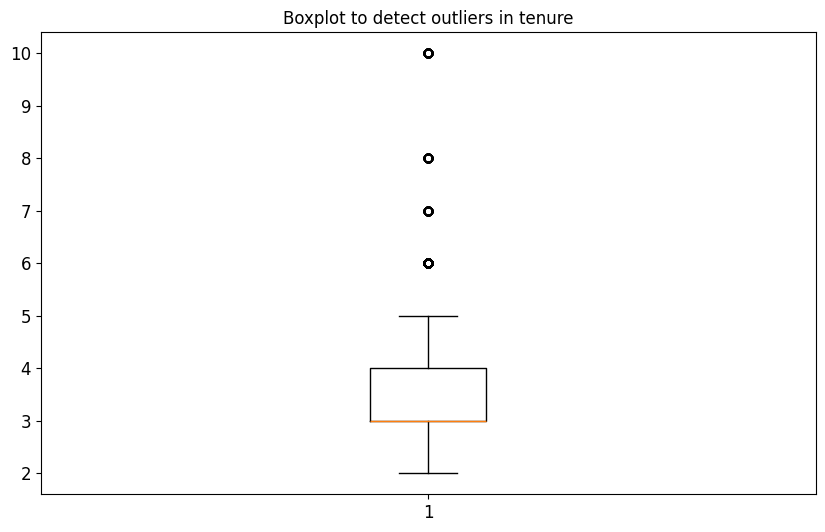

In [10]:
plt.figure(figsize = (10,6))
plt.title('Boxplot to detect outliers in tenure')
plt.boxplot(x = df1['tenure'])
plt.xticks(fontsize =12)
plt.yticks(fontsize =12)
plt.show()

Checking number of outliers

In [11]:
per25 = df1['tenure'].quantile(0.25)
per75 = df1['tenure'].quantile(0.75)

iqr = per75 - per25

upper_lim = per75 + iqr
lower_lim = per25 - iqr

print('Lower Limit', lower_lim)
print('Upper_Limit' , upper_lim)

outliers = df1[(df1['tenure'] > upper_lim) | (df1['tenure'] < lower_lim)]
print('Rows with outlier values in tenure : ', len(outliers))

Lower Limit 2.0
Upper_Limit 5.0
Rows with outlier values in tenure :  824


Whether to remove or keep the outlier values depends on the model we plan to fit to the data. For now, we'll keep the data intact.

# EDA & Data visualization

In [12]:
print(df1['left'].value_counts()) 
print(df1['left'].value_counts(normalize = True))

left
0    10000
1     1991
Name: count, dtype: int64
left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


This is an example of class imbalance. Need to be kept in mind, when splitting datasets for model training.

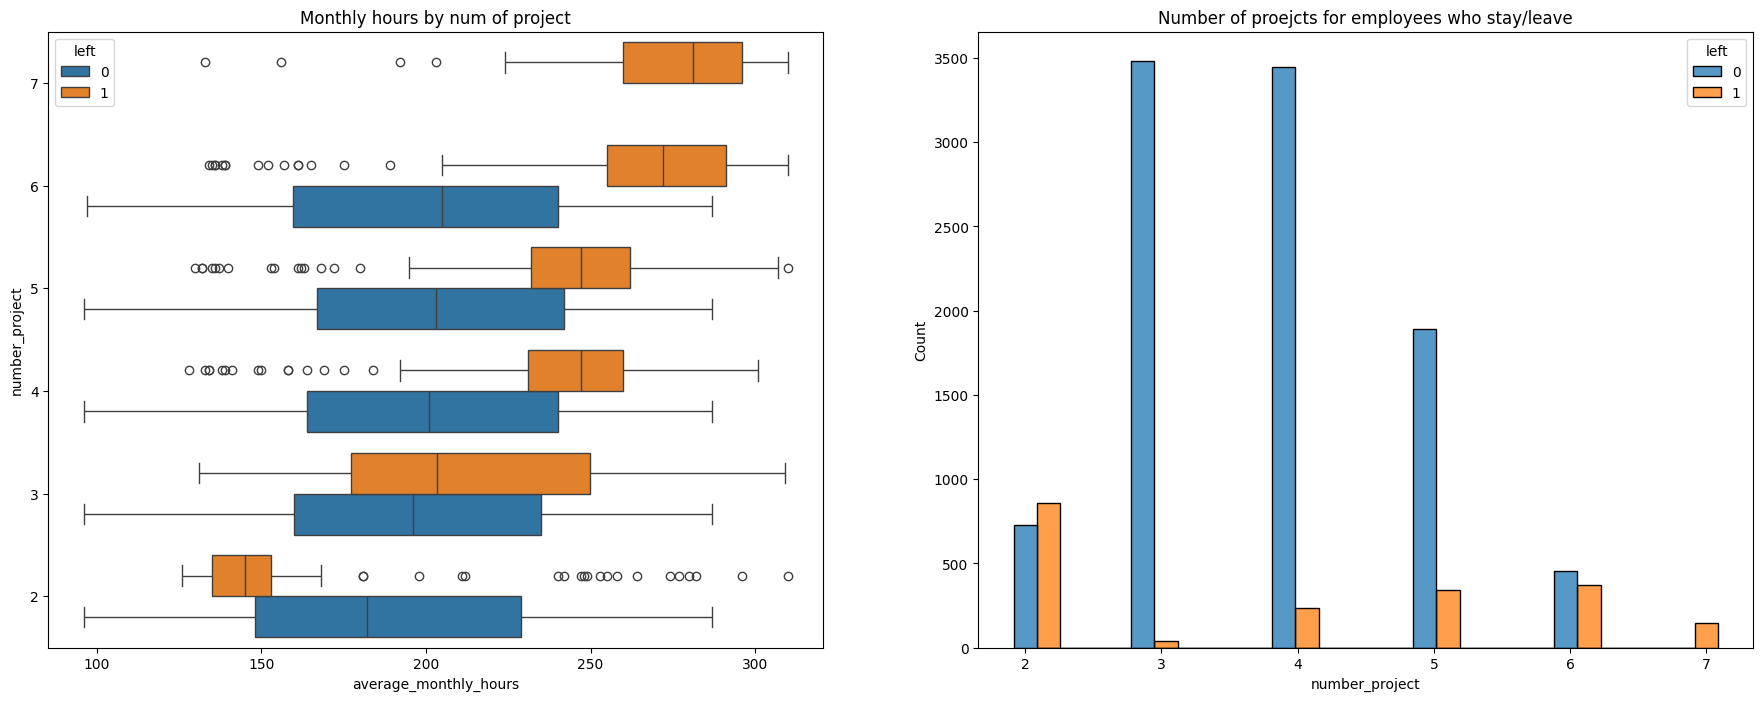

In [13]:
fig, ax = plt.subplots(1 ,2 ,figsize = (22,8))
sns.boxplot(data = df1,x = 'average_monthly_hours' , y = 'number_project' , hue = 'left', orient = 'h', ax = ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by num of project')

sns.histplot(data = df1, x = 'number_project',hue = 'left', multiple = 'dodge', shrink = 2 ,ax = ax[1])
ax[1].set_title('Number of proejcts for employees who stay/leave')
plt.show()

This shows that the employees who left fell into two groups: those who were underworked compared to their peers, and those who were overworked. Calculating 40 hours per week over 50 weeks (excluding 2 weeks of vacation) gives 50 × 40 / 12 ≈ 166.67 hours per month. This means that, aside from employees working on only 2 projects, every group that stayed at the company worked considerably more than this baseline i.e., they were somewhat overworked.

Now that we know working more hours is associated with employees leaving, we can also examine satisfaction levels in relation to this.

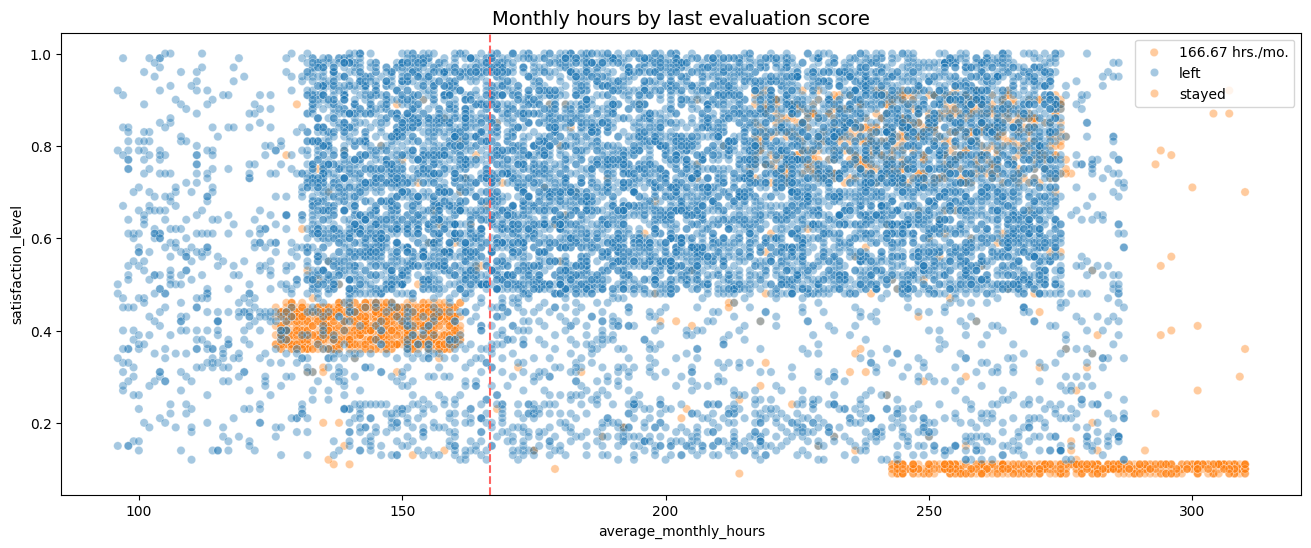

In [14]:
plt.figure(figsize = (16,6))
sns.scatterplot(data = df1, x = 'average_monthly_hours', y = 'satisfaction_level', hue = 'left',alpha = 0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

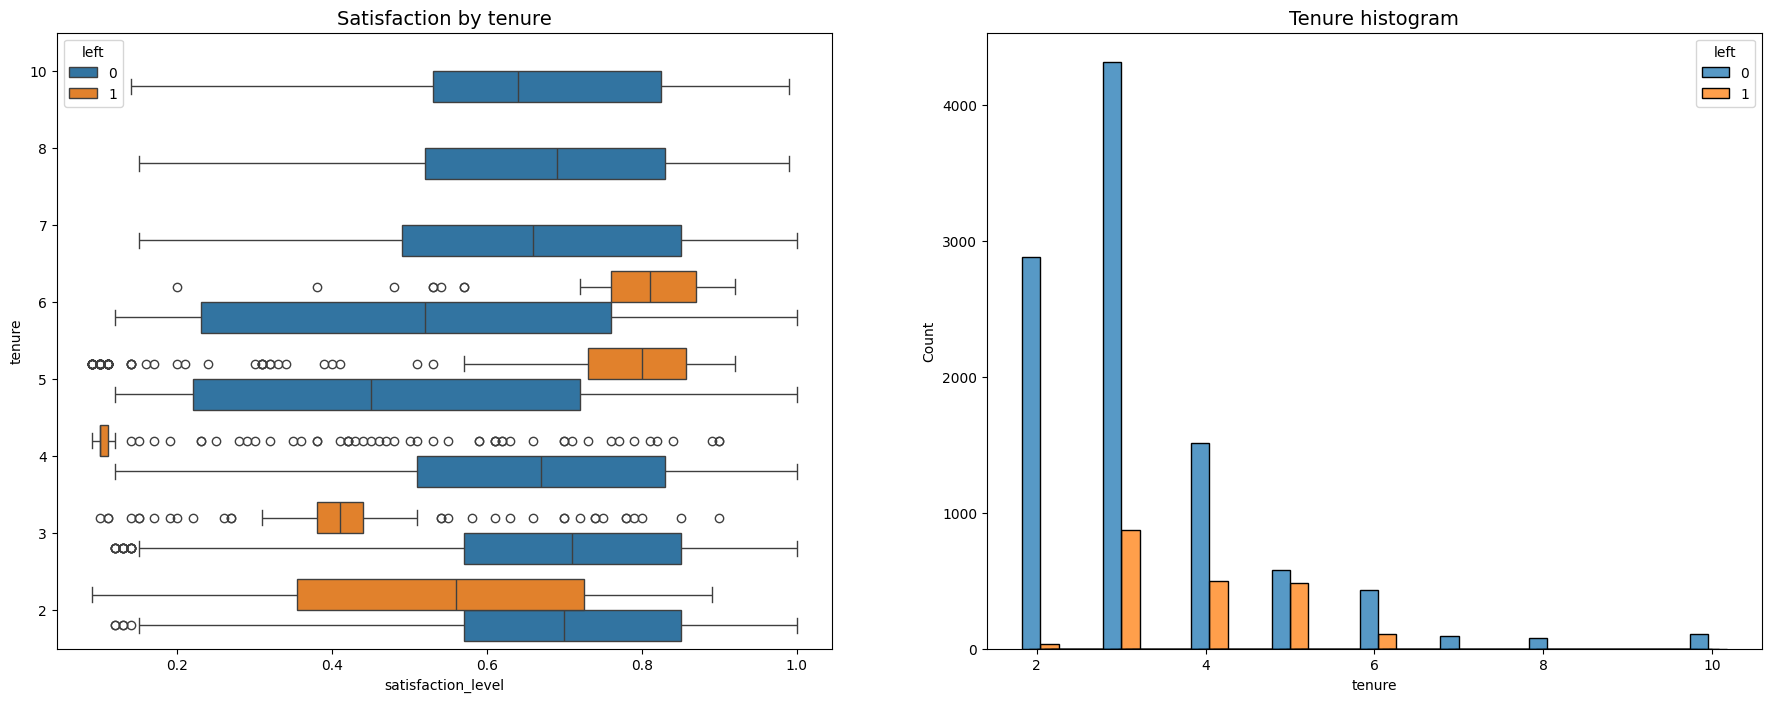

In [15]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))


sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by tenure', fontsize='14')

sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure histogram', fontsize='14')

plt.show();

Employees who left tend to fall into two groups: dissatisfied employees with shorter tenures, and very satisfied employees with medium-length tenures. The longest-tenured employees didn't leave, and their satisfaction is fairly similar to newcomers who stayed. There are very few long-tenured employees, so it's possible they are more highly paid , this relationship is worth checking.

<Axes: xlabel='satisfaction_level', ylabel='left'>

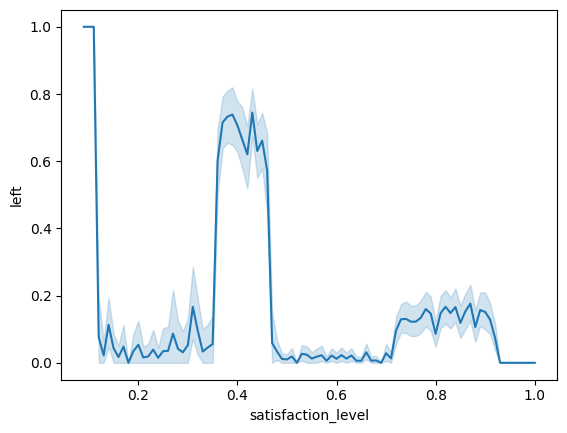

In [16]:
sns.lineplot(data = df1, x = 'satisfaction_level', y = 'left')

This shows that whether an employee leaves isn't determined by satisfaction level alone thus, it's a multi-modal relationship.

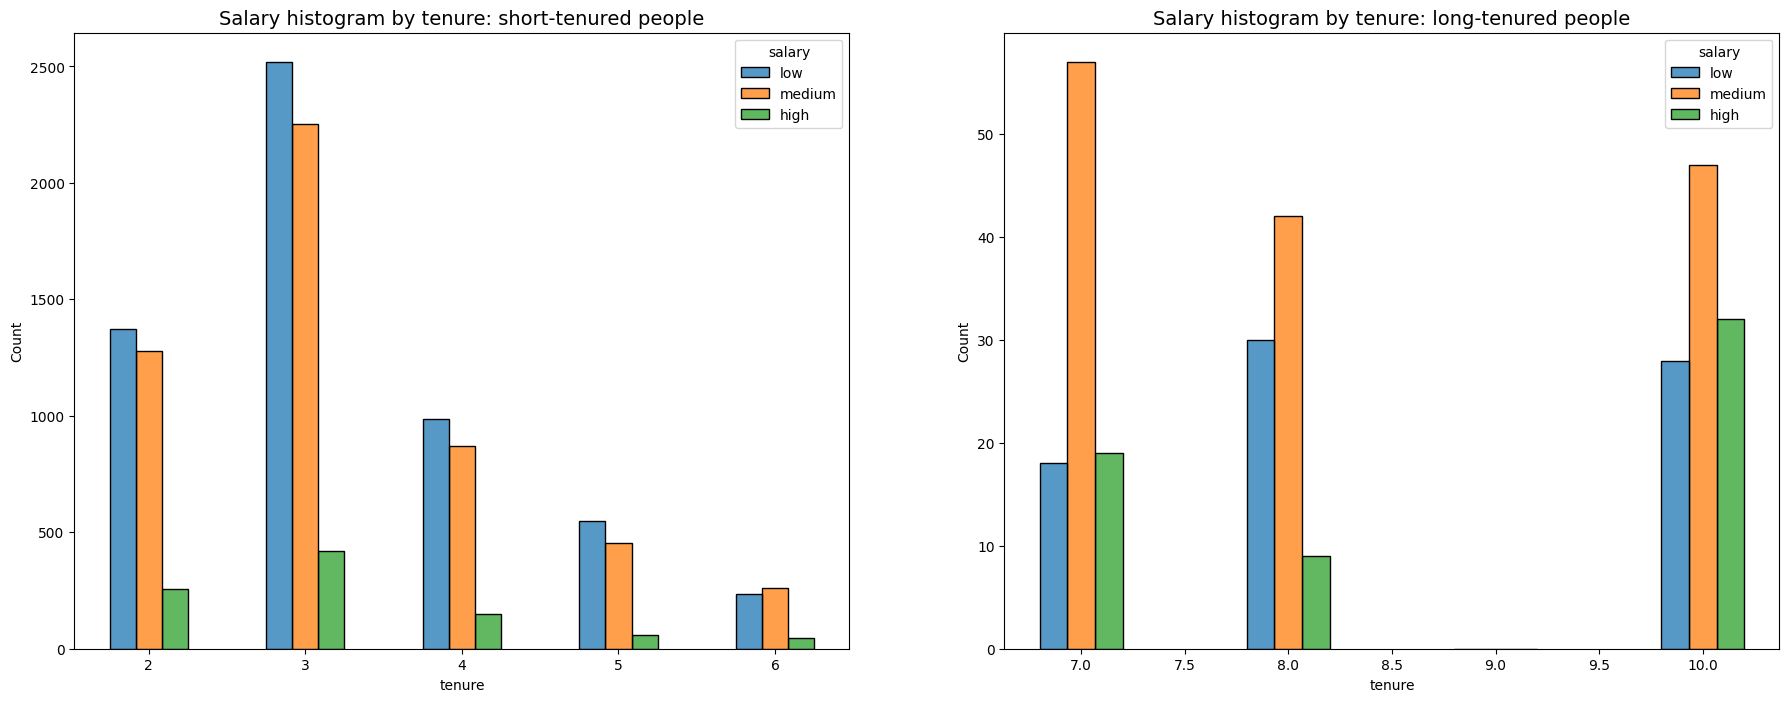

In [17]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

tenure_short = df1[df1['tenure'] < 7]

tenure_long = df1[df1['tenure'] > 6]

sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14');

This contradicts our assumption that long tenure empoloyeed might have a higher salary.

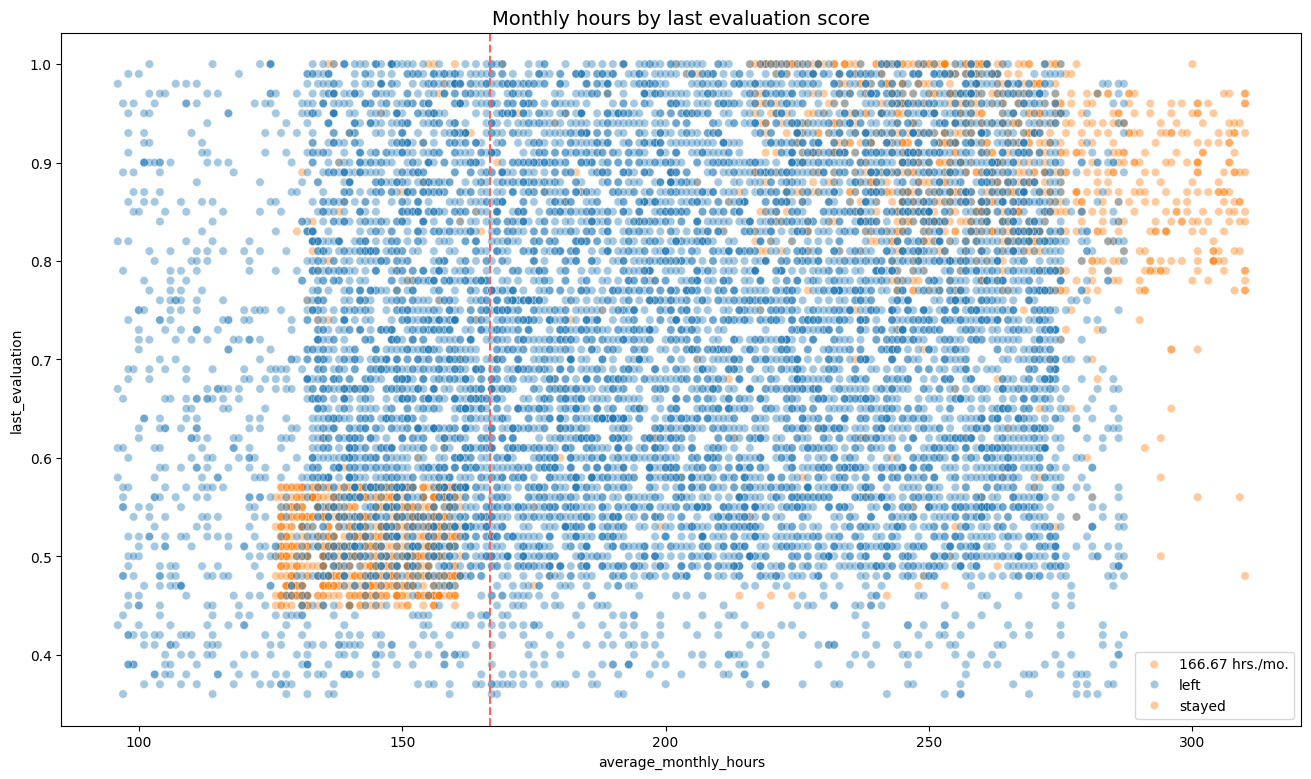

In [18]:
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

Overworked employees who performed well, along with employees who worked slightly under the nominal monthly average of 166.7 hours but had lower evaluation scores, both left the company.

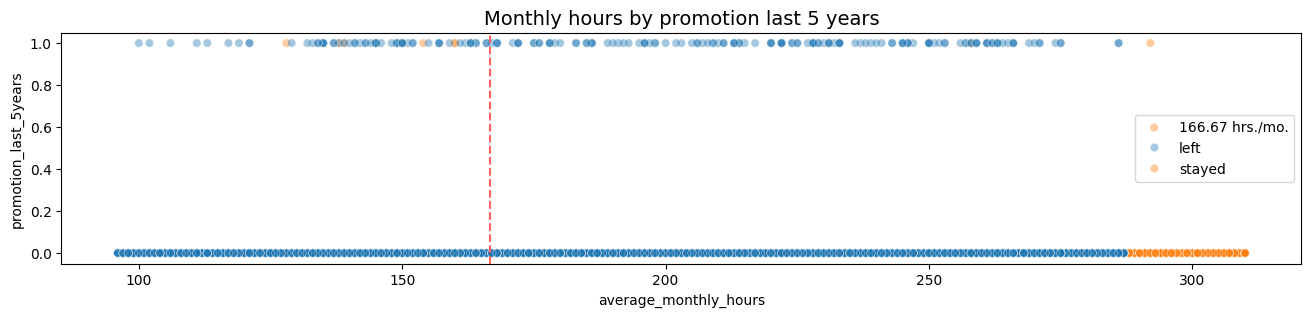

In [19]:
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14');

The plot above shows the following:

- Very few employees who were promoted in the last five years left
- Very few employees who worked the most hours were promoted
- All of the employees who left were among those working the longest hours

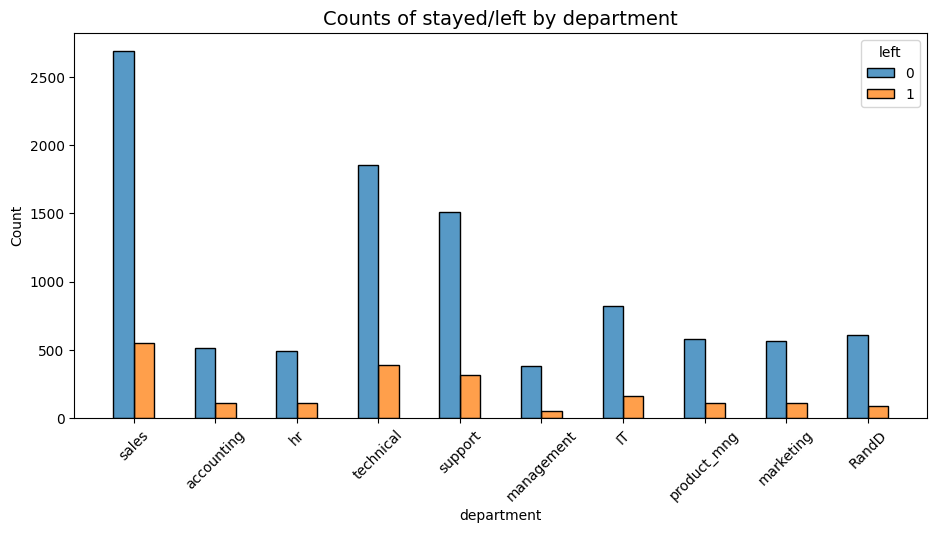

In [20]:
plt.figure(figsize=(11,5))
sns.histplot(data=df1, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of stayed/left by department', fontsize=14);

Department doesnt seem to affect anything in terms of people leaving

In [ ]:
df_heat = df1.copy()
df_heat = df_heat.drop(columns = ['department','salary'],axis=1)
df_heat

In [ ]:
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df_heat.corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

The correlation heatmap confirms that the number of projects, monthly hours, and evaluation scores all have some positive correlation with each other, and whether an employee leaves is negatively correlated with their satisfaction level.

# Modeling

First, let's convert the categorical variables into numerical values.

In [22]:
df_enc = df1.copy()
df_enc['salary'] = df_enc['salary'].astype('category').cat.set_categories(['low','medium','high']).cat.codes
df_enc = pd.get_dummies(df_enc,drop_first = False)

df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


Before implementing the logistic regression model, we'll first check whether there is a linear relationship between the features and the outcome variable, using the logit function.

In [23]:
continuous_vars = ['satisfaction_level', 'last_evaluation', 'average_monthly_hours', 'tenure']

df_test = df_enc.copy()

# Add log-interaction terms (Box-Tidwell)
for var in continuous_vars:
    df_test[f'{var}_log_{var}'] = df_test[var] * np.log(df_test[var].replace(0, 0.0001))

X_vars = continuous_vars + [f'{var}_log_{var}' for var in continuous_vars]
X = sm.add_constant(df_test[X_vars])
y = df_test['left']

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.337399
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                   left   No. Observations:                11991
Model:                          Logit   Df Residuals:                    11982
Method:                           MLE   Df Model:                            8
Date:                Fri, 24 Jul 2026   Pseudo R-squ.:                  0.2495
Time:                        23:26:26   Log-Likelihood:                -4045.7
converged:                       True   LL-Null:                       -5390.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
const                             

According to the results, there is enough evidence to say the variables are not linearly related to the log-odds of the outcome — only one variable failed to reject the null hypothesis, while the rest showed significant evidence against linearity. Thus, a tree-based approach will be the best fit here.

## Tree Based Model

In [24]:
X = df_enc.drop('left', axis=1)   
y = df_enc['left']                  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

###  Decision Tree

In [25]:
dt = DecisionTreeClassifier()

cv_params = {
    'max_depth' : [2,4,6,8 , None],
    'min_samples_leaf' : [2, 5 ,1],
    'min_samples_split' : [ 2 ,4 ,6]
}
scoring = ['accuracy', 'precision', 'recall' , 'f1', 'roc_auc']

dt_cv = GridSearchCV(dt , cv_params, scoring = scoring, refit = 'roc_auc' , cv = 4) 

In [26]:
%%time
dt_cv.fit(X_train,y_train)

CPU times: user 4.24 s, sys: 1.83 ms, total: 4.25 s
Wall time: 4.25 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [27]:
dt_cv.best_params_

{'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 6}

In [28]:
dt_cv.best_score_

np.float64(0.9746135582285558)

In [29]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, accuracy, or auc
  
    Returns a pandas df with the F1, recall, precision, accuracy, and auc scores
    for the model with the best mean 'metric' score across all validation folds.  
    '''

    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    cv_results = pd.DataFrame(model_object.cv_results_)

    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]
                        })
  
    return table

In [30]:
tree1_cv_results = make_results('decision tree cv',dt_cv, 'auc')
tree1_cv_results

,model,precision,recall,F1,accuracy,auc
0,decision tree cv,0.966878,0.918288,0.941941,0.981208,0.974614


### Random Forest Model

In [31]:
rf = RandomForestClassifier(random_state=0)

cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rf1_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [34]:
%%time
rf1_cv.fit(X_train, y_train)

CPU times: user 22min 1s, sys: 877 ms, total: 22min 1s
Wall time: 22min 2s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [3, 5, None], 'max_features': [1.0],
                         'max_samples': [0.7, 1.0],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [300, 500]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [39]:
print(rf1_cv.best_params_)
print('\n Best auc score: ', rf1_cv.best_score_)

{'max_depth': 5, 'max_features': 1.0, 'max_samples': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

 Best auc score:  0.9822377413943887


In [40]:
rf1_cv_results = make_results('random forest cv',rf1_cv,'auc')

In [54]:
def get_scores(model_name: str, model, X_test_data, y_test_data):
    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test,preds)
    accuracy = accuracy_score(y_test,preds)
    precision = precision_score(y_test,preds)
    recall = recall_score(y_test,preds)
    f1 = f1_score(y_test,preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision], 
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })
    return table

In [55]:
from sklearn.metrics import roc_auc_score
rf1_test_scores = get_scores('random forest1 test', rf1_cv, X_test, y_test)
rf1_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest1 test,0.954262,0.921687,0.937692,0.979653,0.956443


# Feature engineering


Satisfaction level typically comes from a self-reported survey that an employee fills out. That means:

- It's not always up to date
- Employees might not answer honestly, especially if they're already planning to leave
- You can't always guarantee this data is available for every employee, every time you want to run the model

For these reasons, I removed satisfaction level as a feature.

In [56]:
df2 = df_enc.drop('satisfaction_level', axis=1)

df2.head()

,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [57]:
df2['overworked'] = df2['average_monthly_hours']

# Inspect max and min average monthly hours values
print('Max hours:', df2['overworked'].max())
print('Min hours:', df2['overworked'].min())

Max hours: 310
Min hours: 96


166.67 is approximately the average number of monthly hours for someone who works 50 weeks per year, 5 days per week, 8 hours per day. Therefore, I converted this into a binary column, flagging values over 175 hours as 1 and all others as 0.

In [58]:
df2['overworked'] = (df2['overworked'] > 175).astype(int)

df2['overworked'].head()

0    0
1    1
2    1
3    1
4    0
Name: overworked, dtype: int64

In [59]:
df2 = df2.drop('average_monthly_hours', axis=1)

df2.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0
1,0.86,5,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
2,0.88,7,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
3,0.87,5,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False,1
4,0.52,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0


In [60]:
y = df2['left']
X = df2.drop('left', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

### Decision tree - Round 2

In [65]:
dt2 = DecisionTreeClassifier(random_state=0)

cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

dt2_cv = GridSearchCV(dt2, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [66]:
%%time
dt2_cv.fit(X_train, y_train)

CPU times: user 3.08 s, sys: 2 ms, total: 3.08 s
Wall time: 3.08 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [68]:
print(dt2_cv.best_params_)
print(dt2_cv.best_score_)

{'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 6}
0.9586752505340426


In [70]:
tree2_cv_results = make_results('decision tree2 cv', dt2_cv, 'auc')
print(tree1_cv_results)
print(tree2_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.966878  0.918288  0.941941  0.981208  0.974614
               model  precision    recall        F1  accuracy       auc
0  decision tree2 cv   0.856693  0.903553  0.878882  0.958523  0.958675


Here, some of the scores dropped, which is expected, but the scores are still very good.

### Random Forest - Round 2

In [74]:
rf2 = RandomForestClassifier(random_state=0)

cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rf2_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [75]:
%%time
rf2_cv.fit(X_train,y_train)

CPU times: user 15min 30s, sys: 871 ms, total: 15min 31s
Wall time: 15min 31s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [3, 5, None], 'max_features': [1.0],
                         'max_samples': [0.7, 1.0],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [300, 500]},
             refit='roc_auc',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [78]:
print(rf2_cv.best_params_)
print(rf2_cv.best_score_)
rf2_cv_results = make_results('random forest2 cv', rf2_cv, 'auc')

{'max_depth': 5, 'max_features': 1.0, 'max_samples': 0.7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
0.9648100662833985


In [80]:
print(tree2_cv_results)
print(rf2_cv_results)

               model  precision    recall        F1  accuracy       auc
0  decision tree2 cv   0.856693  0.903553  0.878882  0.958523  0.958675
               model  precision    recall        F1  accuracy      auc
0  random forest2 cv   0.866758  0.878754  0.872407  0.957411  0.96481


Again, the scores dropped slightly, but the random forest performs better than the decision tree when using AUC as the deciding metric.

Using the champion model on test data.

In [82]:
rf2_test_scores = get_scores('random forest2 test', rf2_cv, X_test, y_test)
rf2_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest2 test,0.870406,0.903614,0.8867,0.961641,0.938407


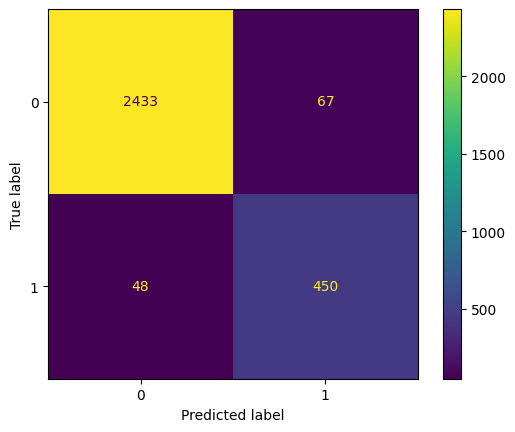

In [83]:
preds = rf2_cv.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=rf2_cv.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=rf2_cv.classes_)
disp.plot(values_format='');

The model predicts more false positives than false negatives, which means that some employees may be identified as at risk of quitting or getting fired, when that's actually not the case. But this is still a strong model.

After conducting feature engineering, the decision tree model achieved AUC of 93.8%, precision of 87.0%, recall of 90.4%, f1-score of 88.7%, and accuracy of 96.2%, on the test set. The random forest modestly outperformed the decision tree model.

### Conclusion
The models and the feature importances extracted from the models confirm that employees at the company are overworked. 

To improve employee retention, the company should consider capping the number of projects assigned to any one employee to prevent overload. Employees with four or more years of tenure may warrant consideration for promotion, and if not, further investigation into why this group reports lower satisfaction would be worthwhile. Rather than expecting long hours as the norm, the company should either fairly compensate employees for the extra time they put in or reduce the pressure to work excessive hours altogether. This includes making sure employees clearly understand overtime pay policies and ensuring expectations around workload and time off are communicated transparently. Beyond individual policies, broader conversations, both company-wide and within specific teams, are needed to understand and address the underlying workplace culture driving these patterns. Finally, evaluation scores shouldn't be reserved almost exclusively for those logging 200+ hours a month; a more proportional system that rewards genuine contribution and effort, rather than raw hours worked, would likely lead to fairer and more sustainable outcomes. 